In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    average_precision_score
)

In [2]:
fraud_df = pd.read_csv(
    "../data/processed/fraud_processed.csv"
)

fraud_df.head()

,purchase_value,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,time_since_signup,hour_of_day,day_of_week,transaction_count,...,country_United States,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
0,54,25,880217484,0,8.724152e+08,8.891924e+08,3564984.0,10,5,1,...,True,False,False,False,False,False,False,False,False,False
1,41,38,2785906106,0,2.785542e+09,2.786066e+09,10039879.0,21,5,1,...,False,False,False,False,False,False,False,False,False,False
2,47,25,356056736,0,3.523215e+08,3.690988e+08,6667201.0,11,3,1,...,True,False,False,False,False,False,False,False,False,False
3,35,19,2985180352,0,2.985034e+09,2.985296e+09,4631485.0,20,2,1,...,False,False,False,False,False,False,False,False,False,False
4,9,32,578312545,0,5.704253e+08,5.872026e+08,3193080.0,12,3,1,...,True,False,False,False,False,False,False,False,False,False


In [3]:
X = fraud_df.drop(
    columns=["class"]
)

y = fraud_df["class"]

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

In [8]:
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [9]:
from imblearn.over_sampling import SMOTE

In [10]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train,
        y_train
    )
)

In [11]:
y_train_smote.value_counts()

class
0    93502
1    93502
Name: count, dtype: int64

In [12]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [13]:
lr_model.fit(
    X_train_smote,
    y_train_smote
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [14]:
y_pred = lr_model.predict(
    X_test
)

In [15]:
y_prob = lr_model.predict_proba(
    X_test
)[:,1]

In [16]:
f1 = f1_score(
    y_test,
    y_pred
)

print(
    f"F1 Score: {f1:.4f}"
)

F1 Score: 0.3180


In [17]:
auc_pr = average_precision_score(
    y_test,
    y_prob
)

print(
    f"AUC-PR: {auc_pr:.4f}"
)

AUC-PR: 0.3443


In [18]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.74      0.83     23376
           1       0.21      0.66      0.32      2454

    accuracy                           0.73     25830
   macro avg       0.58      0.70      0.58     25830
weighted avg       0.88      0.73      0.78     25830



In [19]:
cm = confusion_matrix(
    y_test,
    y_pred
)

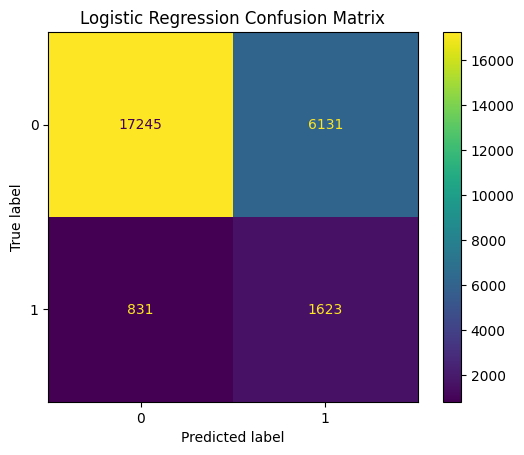

In [20]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

In [21]:
import joblib

In [22]:
joblib.dump(
    lr_model,
    "../models/logistic_regression.pkl"
)

['../models/logistic_regression.pkl']

In [23]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "F1 Score": [f1],
    "AUC-PR": [auc_pr]
})

results

,Model,F1 Score,AUC-PR
0,Logistic Regression,0.317986,0.344304
